#**ALGORITMOS DE BÚSQUEDA EN ACHURA (BFS) Y BÚSQUEDA EN PROFUNDIDAD (DFS)**

##**GRAFO**

        S
       / \
      A   B
     / \   \
    C   D   E
         \ /
          F

##**ALGORITMO BFS (COLA)**

**BÚSQUEDA POR NIVELES**


##**ALGORITMO DFS(PILA)**

**BÚSQUEDA POR RAMA HASTA EL FONDO**

In [1]:
pip install matplotlib imageio

In [9]:
import matplotlib.pyplot as plt
import imageio.v2 as imageio
from collections import deque
import sys

# Grafo
grafo = {
    'S': ['A', 'B'],
    'A': ['C', 'D'],
    'B': ['E'],
    'C': [],
    'D': ['F'],
    'E': ['F'],
    'F': []
}

# Posiciones para dibujar el grafo
pos = {
    'S': (0,3),
    'A': (-1,2),
    'B': (1,2),
    'C': (-1.5,1),
    'D': (-0.5,1),
    'E': (1.5,1),
    'F': (0,0)
}

# Conexiones del grafo
edges = [
    ('S','A'), ('S','B'),
    ('A','C'), ('A','D'),
    ('B','E'),
    ('D','F'), ('E','F')
]

# Función para dibujar cada paso
def dibujar_paso(nodo_actual, paso, algoritmo):

    plt.figure()

    # dibujar conexiones
    for u,v in edges:
        x = [pos[u][0], pos[v][0]]
        y = [pos[u][1], pos[v][1]]
        plt.plot(x,y)

    # dibujar nodos
    for nodo,(x,y) in pos.items():

        if nodo == nodo_actual:
            plt.scatter(x,y,s=1000)
        else:
            plt.scatter(x,y,s=400)

        plt.text(x,y,nodo,ha='center',va='center')

    plt.title(f"{algoritmo} - Paso {paso}: visitando {nodo_actual}")
    plt.axis('off')

    nombre = f"{algoritmo}_paso_{paso}.png"
    plt.savefig(nombre)
    plt.close()

    return nombre


# Función BFS con cálculo de memoria
def bfs(graph, start_node):
    visited = set()
    queue = deque([start_node])
    order = []
    memory_usage = sys.getsizeof(visited) + sys.getsizeof(queue) + sys.getsizeof(order)

    while queue:
        node = queue.popleft()
        if node not in visited:
            visited.add(node)
            order.append(node)
            queue.extend(graph[node])
            # Update memory usage after modifications
            memory_usage = sys.getsizeof(visited) + sys.getsizeof(queue) + sys.getsizeof(order)
    return order, memory_usage


# Función DFS con cálculo de memoria
def dfs(graph, start_node):
    visited = set()
    stack = [start_node]
    order = []
    memory_usage = sys.getsizeof(visited) + sys.getsizeof(stack) + sys.getsizeof(order)

    while stack:
        node = stack.pop()
        if node not in visited:
            visited.add(node)
            order.append(node)
            # Extend stack in reverse to explore in correct DFS order for this graph representation
            for neighbor in reversed(graph[node]):
                stack.append(neighbor)
            # Update memory usage after modifications
            memory_usage = sys.getsizeof(visited) + sys.getsizeof(stack) + sys.getsizeof(order)
    return order, memory_usage


# ---------------- BFS ----------------

orden_bfs, bfs_memoria = bfs(grafo, 'S')

frames_bfs = []

for i,nodo in enumerate(orden_bfs):

    img = dibujar_paso(nodo, i+1, "BFS")
    frames_bfs.append(imageio.imread(img))


imageio.mimsave("bfs_recorrido.gif", frames_bfs, duration=1)


# ---------------- DFS ----------------

orden_dfs, dfs_memoria = dfs(grafo, 'S')

frames_dfs = []

for i,nodo in enumerate(orden_dfs):

    img = dibujar_paso(nodo, i+1, "DFS")
    frames_dfs.append(imageio.imread(img))


imageio.mimsave("dfs_recorrido.gif", frames_dfs, duration=1)


print("GIFs generados:")
print("bfs_recorrido.gif")
print("dfs_recorrido.gif")
print()

print("Resultado BFS:", orden_bfs)
print("Memoria BFS:", bfs_memoria, "bytes")

print()

print("Resultado DFS:", orden_dfs)
print("Memoria DFS:", dfs_memoria, "bytes")

GIFs generados:
bfs_recorrido.gif
dfs_recorrido.gif

Resultado BFS: ['S', 'A', 'B', 'C', 'D', 'E', 'F']
Memoria BFS: 1608 bytes

Resultado DFS: ['S', 'A', 'C', 'D', 'F', 'B', 'E']
Memoria DFS: 936 bytes


##**VISUALIZACIÓN DE LOS RECORRIDOS EN LOS GRAFOS**

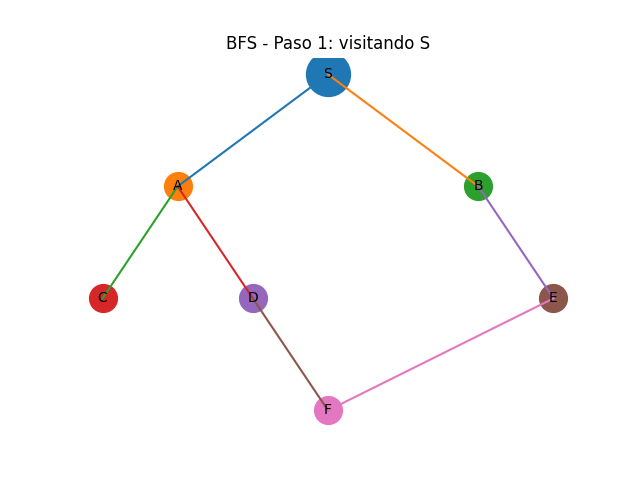

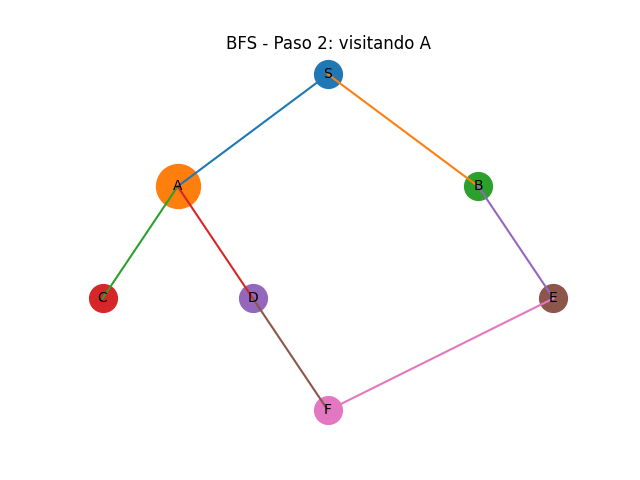

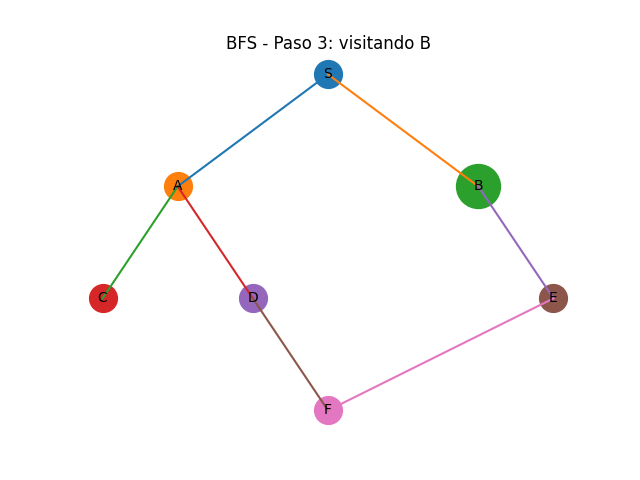

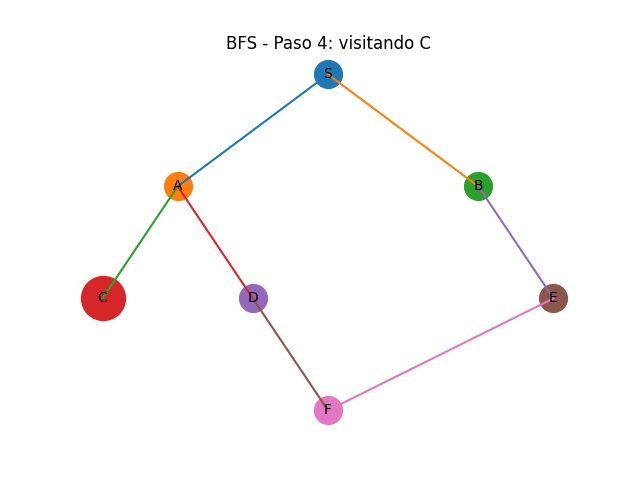

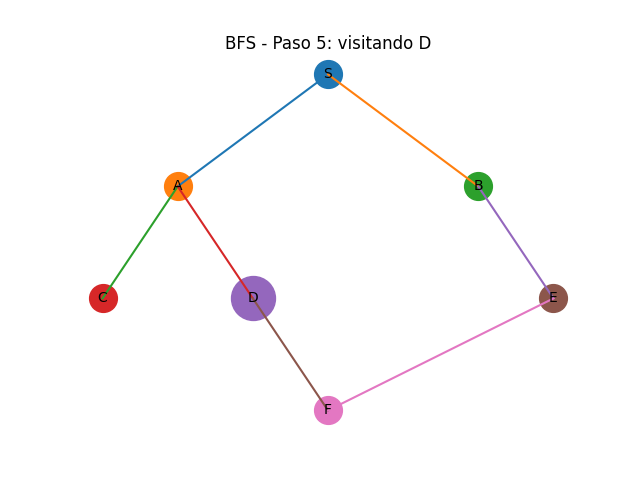

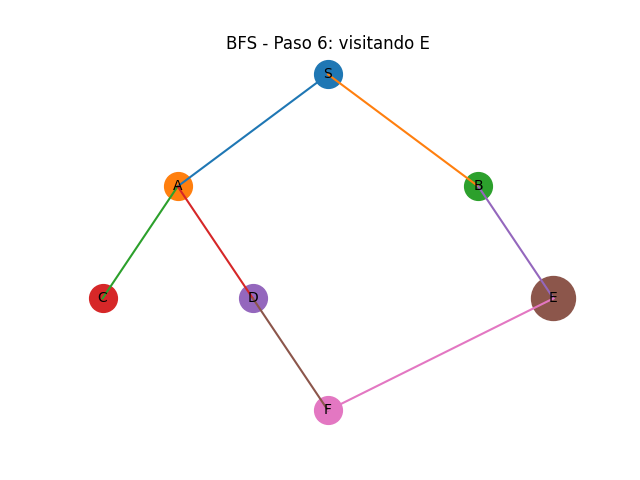

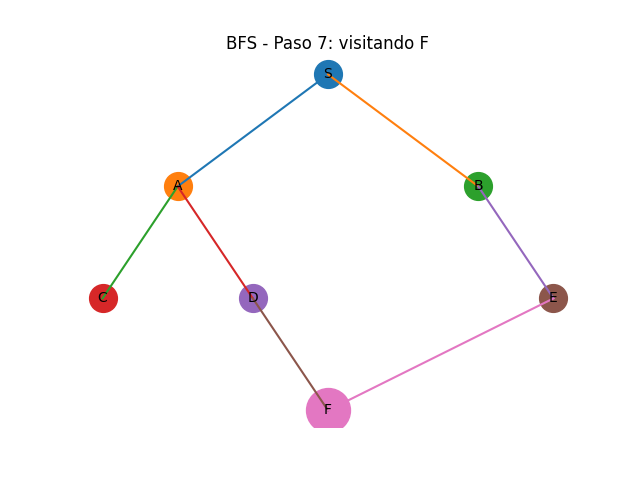

In [5]:
from IPython.display import Image, display

for i in range(1,8):
    url = f"https://raw.githubusercontent.com/Karol-Caicedo/INTELIGENCIA_ARTIFICIAL/main/RECORRIDOS/BFS_paso_{i}.png"
    display(Image(url))

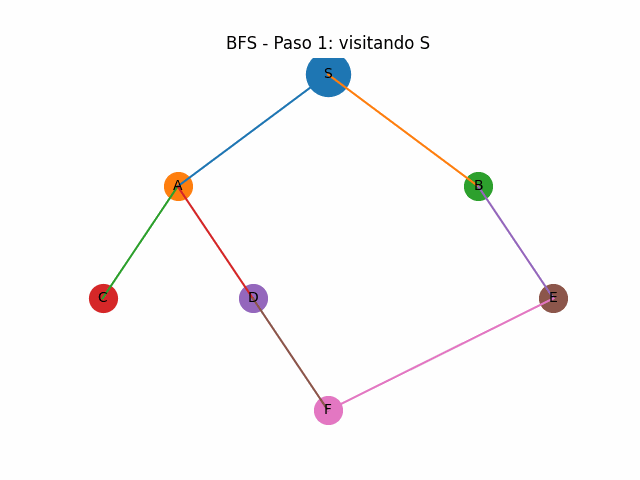

In [6]:
from IPython.display import Image
display(Image(filename='bfs_recorrido.gif'))

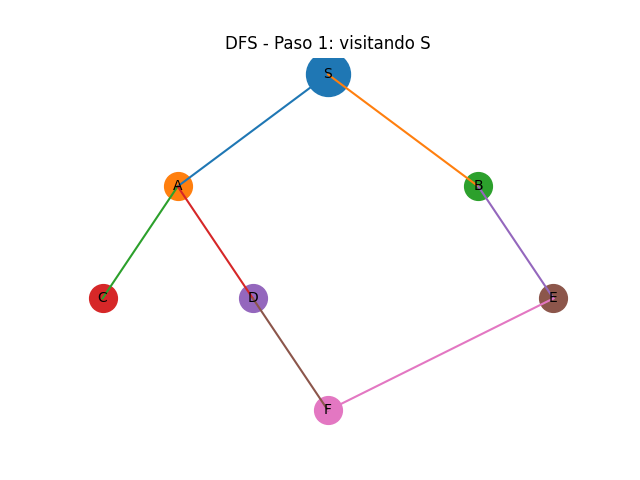

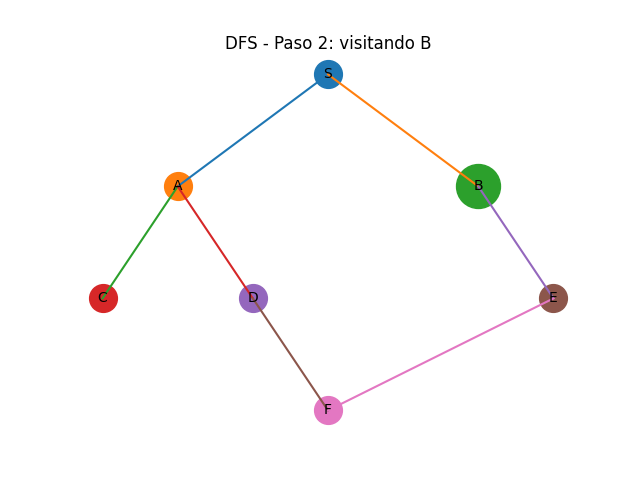

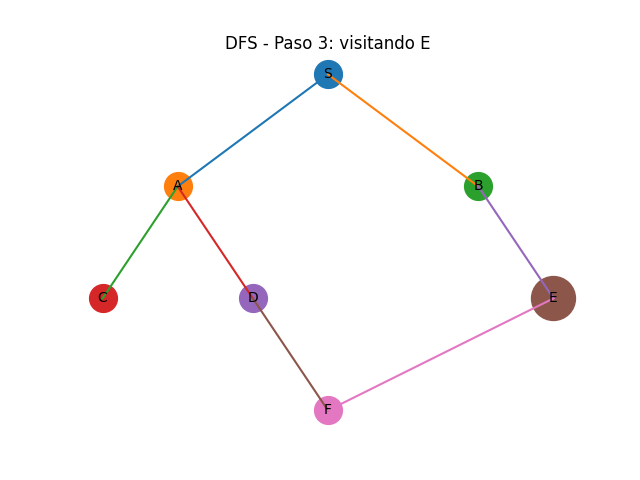

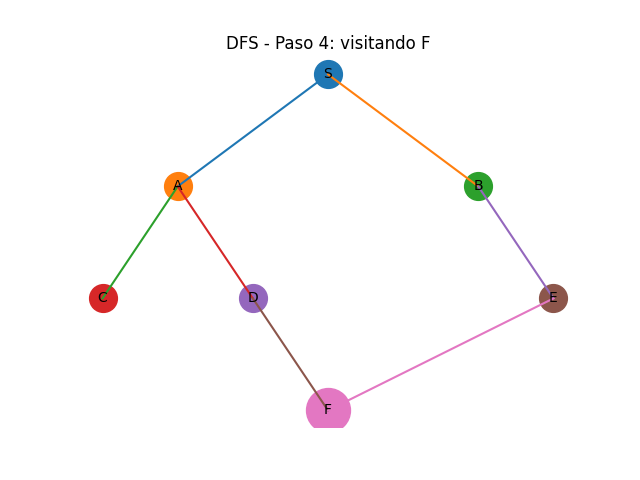

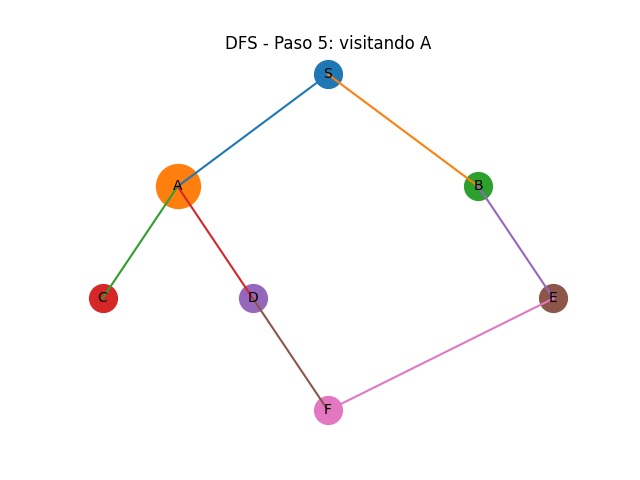

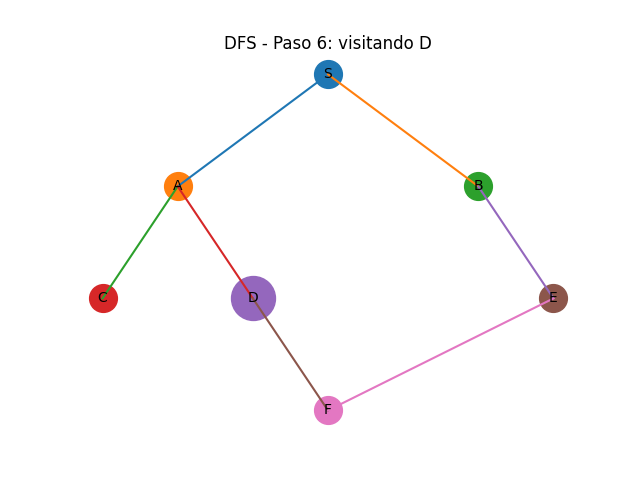

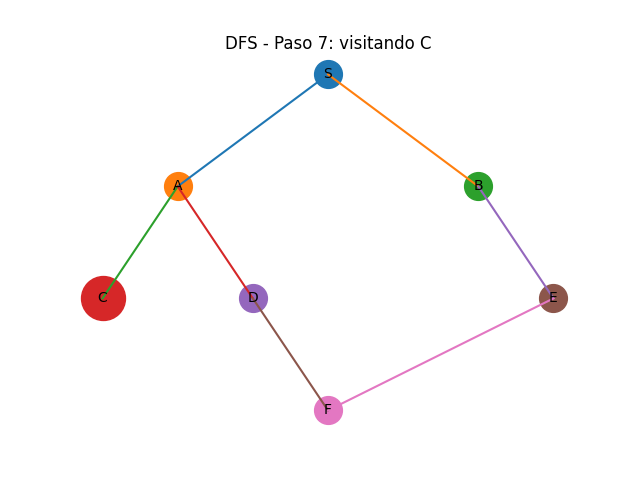

In [7]:
from IPython.display import Image, display

for i in range(1,8):
    url = f"https://raw.githubusercontent.com/Karol-Caicedo/INTELIGENCIA_ARTIFICIAL/main/RECORRIDOS/DFS_paso_{i}.png"
    display(Image(url))

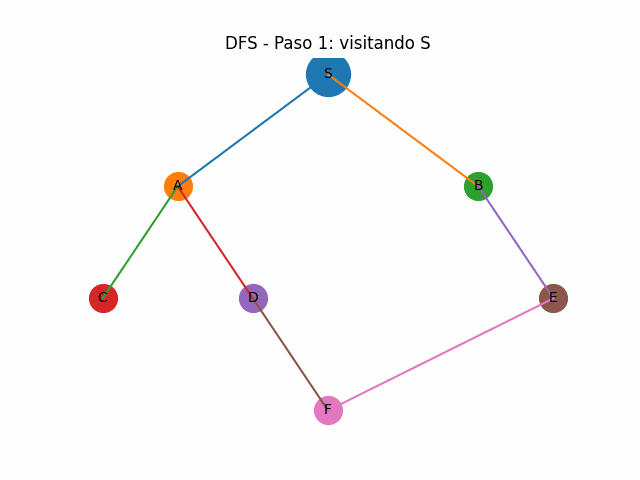

In [8]:
from IPython.display import Image
display(Image(filename='dfs_recorrido.gif'))